Uber
Deliverables:  
1. Data preparation
2. Data cleansing
3. EDA  
4. ML Experimentation
5. Uber fair prediction
6. Business report

Here is all the data you need:
"uber.csv"

In [ ]:
#!pip install --upgrade seaborn numpy scipy matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#For Data Cleaning
from sklearn.impute import SimpleImputer

#For EDA
from scipy import stats
from scipy.stats import norm, skew
import pickle
from scipy.stats import shapiro





## Data loading

Load the Uber dataset.

1. key - a unique identifier for each trip
2. fare_amount - the cost of each trip in usd
3. pickup_datetime - date and time when the meter was engaged
4. passenger_count - the number of passengers in the vehicle (driver entered value)
5. pickup_longitude - the longitude where the meter was engaged
6. pickup_latitude - the latitude where the meter was engaged
7. dropoff_longitude - the longitude where the meter was disengaged
8. dropoff_latitude - the latitude where the meter was disengaged
9. Unnamed: 0 --> unique identifier.

In [ ]:

try:
    df_uber = pd.read_csv('uber.csv')
    display(df_uber.head())
    print(df_uber.shape)
except FileNotFoundError:
    print("Error: 'uber.csv' not found. Please make sure the file exists in the current directory.")
except Exception as e:
    print(f"An error occurred: {e}")

## Data Preparation

understand characteristics of Uber dataset.

1.   Import the dataset and examine its structure
2.   Check for any missing or NaN





In [ ]:
df_uber.columns

In [ ]:

# Examine Data Structure
print(df_uber.info())
print(df_uber.shape)

print("_"*30)

# Identify Missing Values
print(df_uber.isnull().sum())

print("_"*30)

# description of dataset
print(df_uber.describe(include=['O']))

print("_"*30)


print("\nSummary of dateset:")
df_uber.describe()


# Summarize Findings (add your observations here)

In [ ]:
print(df_uber['key'].nunique() == len(df_uber))  # True if all values are unique
print(df_uber['pickup_datetime'].nunique() == len(df_uber))  # True if all values are unique
print(df_uber['Unnamed: 0'].nunique() == len(df_uber))  # True if all values are unique

explore key, pickup_datetime

In [ ]:
df_uber[['key','pickup_datetime']].head(50)

In [ ]:
df_uber['pickup_datetime'].value_counts()

In [ ]:
df_uber[df_uber['pickup_datetime'] == '2009-02-12 12:46:00 UTC']

observation: 'Unnamed: 0','key' are identifier columns so (unnecessary for task)

In [ ]:
df_uber.drop(columns=['Unnamed: 0','key'],inplace=True)

In [ ]:

# Get rows with any missing values
rows_with_missing_values = df_uber[df_uber.isnull().any(axis=1)]

# Display the rows with missing values
rows_with_missing_values



In [ ]:
# Drop rows with any missing values
df_uber.dropna(inplace=True)

# Display the updated DataFrame (optional)
print(df_uber.isnull().sum())


In [ ]:
df_uber.info()

In [ ]:
print(df_uber.duplicated().sum())  # Number of duplicate rows

convert datatime object-typed column:

In [ ]:
df_uber['pickup_datetime'] = pd.to_datetime(df_uber['pickup_datetime'])
df_uber.info()

# feature engineering:

- Rush hours

- Weekend vs weekday pricing

- Night-time surcharges

In [ ]:

df_uber['hour'] = df_uber['pickup_datetime'].dt.hour
df_uber['minute'] = df_uber['pickup_datetime'].dt.minute


df_uber['pickup_dayofweek'] = df_uber['pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
df_uber['pickup_month'] = df_uber['pickup_datetime'].dt.month
df_uber['pickup_year'] = df_uber['pickup_datetime'].dt.year

df_uber["is_weekend"] = df_uber["pickup_dayofweek"].apply(lambda x: 1 if x >= 5 else 0)


def get_time_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:  # 21:00 to 4:59
        return 'Night'

df_uber['time_period'] = df_uber['pickup_datetime'].dt.hour.apply(get_time_period)


feature engineering from coordinates:



1.   Trip Distance (Haversine)
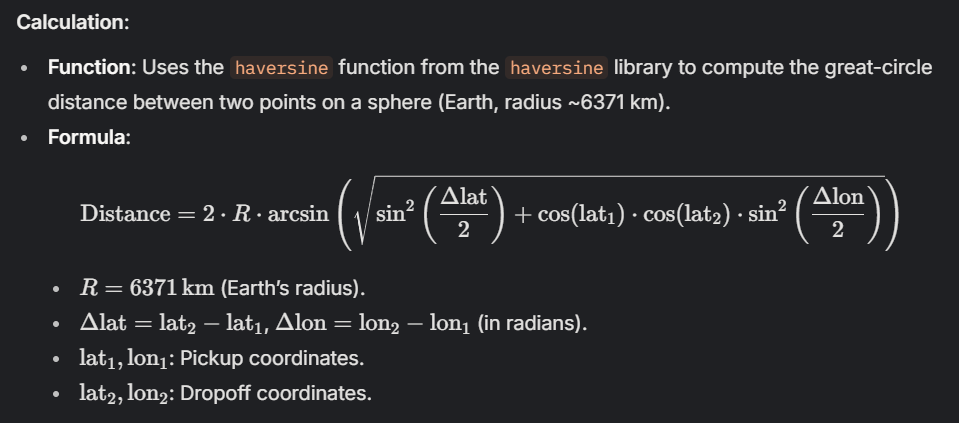
2.   Manhattan Distance: The distance between pickup and dropoff if traveling along a grid-like path (sum of north-south and east-west distances).

3.   Bearing: Indicates the trip’s orientation (e.g., northbound, eastbound).



In [ ]:
!pip install haversine

In [ ]:
from haversine import haversine, Unit

def add_manhattan_distance(df):
    lat1 = np.radians(df['pickup_latitude'])
    lat2 = np.radians(df['dropoff_latitude'])
    lon1 = np.radians(df['pickup_longitude'])
    lon2 = np.radians(df['dropoff_longitude'])

    # Approximate conversion factor (Earth radius ~6371 km)
    km_per_deg_lat = 111  # Constant
    km_per_deg_lon = 111 * np.cos((lat1 + lat2) / 2)  # Adjusted for latitude

    lat_diff_km = np.abs(df['dropoff_latitude'] - df['pickup_latitude']) * km_per_deg_lat
    lon_diff_km = np.abs(df['dropoff_longitude'] - df['pickup_longitude']) * km_per_deg_lon

    df['manhattan_distance_km'] = lat_diff_km + lon_diff_km
    return df


def calculate_bearing(lat1, lon1, lat2, lon2):
    delta_lon = np.radians(lon2 - lon1)
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    y = np.sin(delta_lon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(delta_lon)
    bearing = np.degrees(np.arctan2(y, x))
    return (bearing + 360) % 360



In [ ]:
"""# 1. Trip Distance (Haversine)
df_uber['distance_km'] = df_uber.apply(
    lambda row: haversine(
        (row['pickup_latitude'], row['pickup_longitude']),
        (row['dropoff_latitude'], row['dropoff_longitude']),
        unit=Unit.KILOMETERS
    ), axis=1
)

# 2. Manhattan Distance
df_uber = add_manhattan_distance(df_uber)


# 3. Bearing
df_uber['bearing'] = df_uber.apply(
    lambda row: calculate_bearing(
        row['pickup_latitude'], row['pickup_longitude'],
        row['dropoff_latitude'], row['dropoff_longitude']
    ), axis=1
)"""

clean coordinations for feature engineering:

In [ ]:
geographical_features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
# see descrition of them
df = df_uber[geographical_features]
df.describe()

In [ ]:
# Check for out-of-bound coordinates
invalid_coords = df_uber[
    (df['pickup_longitude'] < -180) | (df['pickup_longitude'] > 180) |
    (df['dropoff_longitude'] < -180) | (df['dropoff_longitude'] > 180) |
    (df['pickup_latitude'] < -90) | (df['pickup_latitude'] > 90) |
    (df['dropoff_latitude'] < -90) | (df['dropoff_latitude'] > 90)
]
invalid_coords

invalid cases:
-
-
-

In [ ]:

# Flag invalid coordinates
df_uber['invalid_coords'] = (
    # Out-of-bound coordinates
    (df_uber['pickup_longitude'] < -180) | (df_uber['pickup_longitude'] > 180) |
    (df_uber['dropoff_longitude'] < -180) | (df_uber['dropoff_longitude'] > 180) |
    (df_uber['pickup_latitude'] < -90) | (df_uber['pickup_latitude'] > 90) |
    (df_uber['dropoff_latitude'] < -90) | (df_uber['dropoff_latitude'] > 90) |
    # Full zero coordinates
    ((df_uber['pickup_longitude'] == 0) & (df_uber['pickup_latitude'] == 0)) |
    ((df_uber['dropoff_longitude'] == 0) & (df_uber['dropoff_latitude'] == 0)) |
    # Partial zero coordinates
    (df_uber['pickup_longitude'] == 0) | (df_uber['pickup_latitude'] == 0) |
    (df_uber['dropoff_longitude'] == 0) | (df_uber['dropoff_latitude'] == 0)
)

# Print summary
print(f"Invalid rows: {df_uber['invalid_coords'].sum()} ({df_uber['invalid_coords'].mean()*100:.4f}%)")
print(df_uber[df_uber['invalid_coords']][['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'fare_amount']].head(12))

In [ ]:
# Step 1: Flag Invalid Coordinates
df_uber['invalid_coords'] = (
    # Full zero coordinates
    ((df_uber['pickup_longitude'] == 0) & (df_uber['pickup_latitude'] == 0)) |
    ((df_uber['dropoff_longitude'] == 0) & (df_uber['dropoff_latitude'] == 0)) |
    # Partial zero coordinates
    (df_uber['pickup_longitude'] == 0) | (df_uber['pickup_latitude'] == 0) |
    (df_uber['dropoff_longitude'] == 0) | (df_uber['dropoff_latitude'] == 0)
)

df_uber['out_of_bound'] = (
    (df_uber['pickup_longitude'] < -180) | (df_uber['pickup_longitude'] > 180) |
    (df_uber['dropoff_longitude'] < -180) | (df_uber['dropoff_longitude'] > 180) |
    (df_uber['pickup_latitude'] < -90) | (df_uber['pickup_latitude'] > 90) |
    (df_uber['dropoff_latitude'] < -90) | (df_uber['dropoff_latitude'] > 90)
)

print(f"Total invalid rows: {df_uber['invalid_coords'].sum()} ({df_uber['invalid_coords'].mean()*100:.4f}%)")
print(f"Out-of-bound rows: {df_uber['out_of_bound'].sum()}")

In [ ]:
# Step 2: Replace One or Two Out-of-Bound Coordinates with 0
def count_out_of_bound(row):
    count = sum([
        row['pickup_longitude'] < -180 or row['pickup_longitude'] > 180,
        row['pickup_latitude'] < -90 or row['pickup_latitude'] > 90,
        row['dropoff_longitude'] < -180 or row['dropoff_longitude'] > 180,
        row['dropoff_latitude'] < -90 or row['dropoff_latitude'] > 90
    ])
    return count

df_uber['out_of_bound_count'] = df_uber.apply(count_out_of_bound, axis=1)
df_uber['out_of_bound_count'].value_counts()

In [ ]:
# Replace out-of-bound with 0 for rows with 1 or 2 out-of-bound coordinates
mask = (df_uber['out_of_bound']) & (df_uber['out_of_bound_count'].isin([1, 2]))
df_uber.loc[mask, 'pickup_longitude'] = df_uber.loc[mask, 'pickup_longitude'].apply(lambda x: 0 if x < -180 or x > 180 else x)
df_uber.loc[mask, 'pickup_latitude'] = df_uber.loc[mask, 'pickup_latitude'].apply(lambda x: 0 if x < -90 or x > 90 else x)
df_uber.loc[mask, 'dropoff_longitude'] = df_uber.loc[mask, 'dropoff_longitude'].apply(lambda x: 0 if x < -180 or x > 180 else x)
df_uber.loc[mask, 'dropoff_latitude'] = df_uber.loc[mask, 'dropoff_latitude'].apply(lambda x: 0 if x < -90 or x > 90 else x)

# Update invalid_coords to include new zeros
df_uber.loc[mask, 'invalid_coords'] = True
df_uber.loc[mask, 'out_of_bound'] = False  # No longer out-of-bound
print(f"Rows with out-of-bound replaced with 0: {mask.sum()}")

drop rows with:
- identical pickup, dropoff
- more than 2 values out of boundry

In [ ]:
# Step 3: Remove Rows with Three or Four Out-of-Bound Coordinates & identical locations
df_uber = df_uber[~((df_uber['out_of_bound']) & (df_uber['out_of_bound_count'] >= 3))].copy()
df_uber['invalid_coords'] = df_uber['invalid_coords'] & ~df_uber['out_of_bound']
df_uber = df_uber.drop(columns=['out_of_bound', 'out_of_bound_count'])


print(f"Dataset size after removing unrecoverable out-of-bound: {df_uber.shape[0]} rows")
print(f"Remaining invalid rows: {df_uber['invalid_coords'].sum()}")

In [ ]:

def drop_identical_points(df, drop_flag):
    """
    Drops rows with identical pickup and dropoff points based on a flag.

    Args:
        df: The input DataFrame.
        drop_flag: A boolean flag. If True, drops identical points; otherwise, returns the DataFrame unchanged.

    Returns:
        A DataFrame with or without identical points dropped, depending on the drop_flag.
    """
    identical_points = df[
        (df['pickup_longitude'] == df['dropoff_longitude']) &
        (df['pickup_latitude'] == df['dropoff_latitude'])
    ]

    if drop_flag:
        df_dropped = df.drop(identical_points.index)
        return df_dropped
    else:
        return df



df_uber = drop_identical_points(df_uber, drop_flag=True)


In [ ]:
print(f"Remaining invalid rows: {df_uber['invalid_coords'].sum()}")
df_uber.info()

In [ ]:
#!pip install haversine

In [ ]:
#!pip install numpy==2.0

In [ ]:
from haversine import haversine, Unit

# 1. Trip Distance (Haversine)
df_uber['distance_km'] = df_uber.apply(
    lambda row: haversine(
        (row['pickup_latitude'], row['pickup_longitude']),
        (row['dropoff_latitude'], row['dropoff_longitude']),
        unit=Unit.KILOMETERS
    ), axis=1
)

# 2. Manhattan Distance
df_uber = add_manhattan_distance(df_uber)


# 3. Bearing
df_uber['bearing'] = df_uber.apply(
    lambda row: calculate_bearing(
        row['pickup_latitude'], row['pickup_longitude'],
        row['dropoff_latitude'], row['dropoff_longitude']
    ), axis=1
)

dropped identical, invalid rows of coordinates then calcuilate new features

# data cleansing

1. fare_count

In [ ]:
# Explore negative values in 'fare_amount'

negative_fares = df_uber[df_uber['fare_amount'] < 0]
print("negative rows count:")
print(len(negative_fares))
print("Rows with negative fare amounts:")
print(negative_fares)

# Analyze the distribution of negative fare amounts
print("\nDescription of negative fare amounts:")
print(negative_fares['fare_amount'].describe())

# Visualize the distribution of negative fare amounts (if any exist)
if not negative_fares.empty:
    plt.figure(figsize=(8, 6))
    sns.histplot(negative_fares['fare_amount'], kde=True)
    plt.title('Distribution of Negative Fare Amounts')
    plt.xlabel('Fare Amount')
    plt.ylabel('Frequency')
    plt.show()


# Replace negative values in 'fare_amount' with NaN
df_uber['fare_amount'] = df_uber['fare_amount'].apply(lambda x: np.nan if x < 0 else x)
df_uber[df_uber['fare_amount'] < 0]


1.   There are 17 rows with negative fare amounts.
2.   The values range from -52 to -3.

Negative fare amounts are most likely data entry errors or anomalies.




2. passengers_count



1.   0 passenger count is not valid (as the taxi ride cannot have zero passengers). but can be reasoned as transportation

2.   
208 passenger count is an extreme outlier that likely represents a data entry mistake or a system error.

In [ ]:
# to be considered transpotaion

zero_passen = df_uber[df_uber['passenger_count'] == 0]
display(zero_passen['fare_amount'].value_counts())

# Explore negative values
negative_passengers = df_uber[df_uber['passenger_count'] < 0]
print("\nRows with negative passenger counts:")


# Drop rows where 'passenger_count' is 208
df_uber = df_uber[df_uber['passenger_count'] != 208]

3- coordinates

In [ ]:
(df_uber['distance_km'] < 1).sum()

In [ ]:
# Step 4: Impute Recoverable Rows Using Clustering
valid_coords = df_uber[
    (~df_uber['invalid_coords']) &
    (df_uber['pickup_longitude'].notnull()) &
    (df_uber['dropoff_longitude'].notnull())
][['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']]
len(valid_coords)

In [ ]:
# invalid data

# Step 4: Impute Recoverable Rows Using Clustering
invalid_coords = df_uber[
    (df_uber['invalid_coords'])
]

invalid_coords

In [ ]:
invalid_pickups = invalid_coords[(invalid_coords['pickup_latitude'] == 0) | (invalid_coords['pickup_longitude'] == 0)]
invalid_pickups

In [ ]:
from folium.plugins import HeatMap
import folium

# Create a base map
nyc_map = folium.Map(location=[40.68, -74.00], zoom_start=11)

# Add pickup locations as a heatmap
heat_data = list(zip(invalid_pickups['pickup_latitude'], invalid_pickups['pickup_longitude']))
HeatMap(heat_data[:]).add_to(nyc_map)  # Limit to 10k points for speed

# Show the map
nyc_map

In [ ]:

# Drop rows with invalid coordinates
df_uber = df_uber[~df_uber['invalid_coords']]

# Print the number of remaining rows
print(f"Dataset size after dropping invalid coordinates: {df_uber.shape[0]} rows")


In [ ]:

# Outlier exploration for numerical features
numerical_features = df_uber.select_dtypes(include=np.number).columns
# Calculate the number of rows and columns for subplots
num_rows = (len(numerical_features) + 2) // 3  # Adjust calculation for rows
num_cols = 3

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)  # Use calculated num_rows
    sns.boxplot(y=df_uber[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


# Statistical analysis for outliers (using IQR)
for col in numerical_features:
    Q1 = df_uber[col].quantile(0.25)
    Q3 = df_uber[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_uber[(df_uber[col] < lower_bound) | (df_uber[col] > upper_bound)]
    print(f"Outliers in {col}:")
    print(len(outliers[[col]]))  # Print only the relevant column for outliers
    print("-" * 20)



discover possible invalid cases for disatance , passenger, fareamount

In [ ]:
df_uber[((df_uber['fare_amount'] > 150))]

In [ ]:
df_uber[((df_uber['fare_amount'] > 150) & (df_uber['distance_km'] < 0.1))]

In [ ]:
df_uber = df_uber[~((df_uber['fare_amount'] > 150) & (df_uber['distance_km'] < 12))]

In [ ]:
df_low_disatnce = df_uber[df_uber['distance_km'] < 1]
print(df_low_disatnce[['fare_amount','distance_km']].describe())

# relation between thw two columns values to see if ther is any bias
df_low_disatnce.plot(x='fare_amount', y='distance_km', kind='scatter')


In [ ]:
df_uber[df_uber['fare_amount'] == 0]

In [ ]:
df_uber = df_uber[~(df_uber['fare_amount'] == 0)]

# EDA



*   Outlier Detection
*   Consistency extra Check



In [ ]:
#! pip install ydata_profiling

In [ ]:
"""from ydata_profiling import ProfileReport

profile = ProfileReport(df_uber, title="Profiling Report")
profile.to_notebook_iframe()"""

In [ ]:

# Assuming df_uber is your DataFrame
df_uber.dropna(subset=['fare_amount'], inplace=True)


In [ ]:
# check null
print(df_uber.isna().sum())

# check duplicates
print(df_uber.duplicated().sum())

In [ ]:
# Histograms for numerical columns
numerical_cols = df_uber.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df_uber[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

#plt.savefig('univariate_histograms.png')
plt.close()

In [ ]:
import math

# Set up subplot grid
n_cols = len(numerical_cols)
n_rows = math.ceil(n_cols / 4)  # 4 columns per row, adjust as needed
fig, axes = plt.subplots(n_rows, min(n_cols, 4), figsize=(min(n_cols, 4) * 4, n_rows * 4), squeeze=False)

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop through numerical columns
for i, col in enumerate(numerical_cols):
    # Print value counts
    print(f"\nDistribution and Value Counts for '{col}':")
    print(df_uber[col].value_counts().sort_index())

    # Create boxplot in subplot
    sns.boxplot(y=df_uber[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Hide empty subplots (if any)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Adjust layout and save
plt.tight_layout()
plt.savefig('numerical_boxplots.png')
plt.show()
plt.close()
print("All boxplots saved as 'numerical_boxplots.png'")

from observations of value_count and outliers detection

In [ ]:
df_uber = df_uber[~(df_uber['fare_amount'] < 2.5)]

In [ ]:
from folium.plugins import HeatMap
import folium

# Create a base map
nyc_map = folium.Map(location=[40.68, -74.00], zoom_start=11)

# Add pickup locations as a heatmap
heat_data = list(zip(df_uber['pickup_latitude'], df_uber['pickup_longitude']))
HeatMap(heat_data[:]).add_to(nyc_map)  # Limit to 10k points for speed

# Show the map
nyc_map

In [ ]:

# Create a base map
nyc_map = folium.Map(location=[40.68, -74.00], zoom_start=11)

# Add pickup locations as a heatmap
heat_data = list(zip(df_uber['dropoff_latitude'], df_uber['dropoff_longitude']))
HeatMap(heat_data[:]).add_to(nyc_map)  # Limit to 10k points for speed

# Show the map
nyc_map

In [ ]:
df_uber.describe()

In [ ]:
# handle outliers

1- fare_amount

- Outliers: Values above ~$100, with some reaching $500.
- Handling: Cap at the 95th percentile (~$25, based on describe() Q3 $12.5, max $499). Research suggests capping at 95th percentile for skewed fares

In [ ]:

def detect_outliers_iqr(data, column):
    """
    Detects outliers in a pandas Series using the Interquartile Range (IQR) method.

    Args:
        data: The pandas DataFrame containing the data.
        column: The name of the column to analyze.

    Returns:
        A pandas Series with boolean values indicating whether each data point is an outlier.
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    print("lower: ",lower_bound)

    upper_bound = Q3 + 1.5 * IQR
    print("upper: ",upper_bound)
    return (data[column] < lower_bound) | (data[column] > upper_bound),lower_bound,upper_bound




In [ ]:
outliers, lower,higher = detect_outliers_iqr(df_uber, 'fare_amount')
print(outliers.value_counts())

df_uber[outliers]['fare_amount'].value_counts()

In [ ]:
fare_95th = df_uber['fare_amount'].quantile(0.99)
print(fare_95th)
#df_uber['fare_amount'] = df_uber['fare_amount'].apply(lambda x: fare_95th if x > fare_95th else x)

In [ ]:

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data[column] < lower_bound) | (data[column] > upper_bound), lower_bound, upper_bound

# Assuming 'df_uber' is your DataFrame
df_uber['suspected_coordinate'] = False

for col in ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']:
    outliers, lower_bound, upper_bound = detect_outliers_iqr(df_uber, col)
    df_uber.loc[outliers, 'suspected_coordinate'] = True

df_uber['suspected_coordinate'].value_counts()


In [ ]:
data_valid = df_uber[~df_uber['suspected_coordinate']]
# Create a base map
nyc_map = folium.Map(location=[40.68, -74.00], zoom_start=11)

# Add pickup locations as a heatmap
heat_data = list(zip(data_valid['dropoff_latitude'], data_valid['dropoff_longitude']))
HeatMap(heat_data[:]).add_to(nyc_map)  # Limit to 10k points for speed

# Show the map
nyc_map

In [ ]:
data_invalid = df_uber[df_uber['suspected_coordinate']]
# Create a base map
nyc_map = folium.Map(location=[40.68, -74.00], zoom_start=11)

# Add pickup locations as a heatmap
heat_data = list(zip(data_invalid['dropoff_latitude'], data_invalid['dropoff_longitude']))
HeatMap(heat_data[:]).add_to(nyc_map)  # Limit to 10k points for speed

# Show the map
nyc_map

In [ ]:
# detect locations of water


In [ ]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from haversine import haversine, Unit

In [ ]:
# chech the rows of
data_invalid[data_invalid['pickup_longitude'].between(-1,1)|data_invalid['pickup_latitude'].between(-1,1)]

In [ ]:
data_invalid.describe()

In [ ]:
dd = data_invalid.copy()
dd


In [ ]:

dd = dd[(
    (dd['dropoff_latitude'].between(0,30)) |
    (dd['dropoff_longitude'].between(-73.5,1)) |
    (dd['dropoff_latitude'].between(-90,-60)) |
    (dd['pickup_latitude'].between(0,30)) |
    (dd['pickup_longitude'].between(-73.5,1)) |
    (dd['pickup_latitude'].between(-90,-60)) |
    (dd['pickup_latitude'].between(-40,40))
  )
]
dd

2- coordinates:

In [ ]:

df_uber = df_uber.drop(dd.index)


In [ ]:
nyc_map = folium.Map(zoom_start=11)

# Add pickup locations as a heatmap
heat_data = list(zip(df_uber['pickup_latitude'], df_uber['pickup_longitude']))
HeatMap(heat_data[:]).add_to(nyc_map)  # Limit to 10k points for speed

# Show the map
nyc_map

In [ ]:
df_uber['suspected_coordinate'].sum()

In [ ]:
suspected = df_uber[df_uber['suspected_coordinate']].copy()
len(suspected)

In [ ]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# Load water shapefiles
oceans = gpd.read_file("ne_10m_ocean/ne_10m_ocean.shp")
lakes = gpd.read_file("ne_10m_lakes/ne_10m_lakes.shp")
rivers = gpd.read_file("ne_10m_rivers_lake_centerlines/ne_10m_rivers_lake_centerlines.shp")

# Combine all water bodies into a single GeoDataFrame
water_bodies = pd.concat([oceans, lakes, rivers], ignore_index=True).to_crs("EPSG:4326")

# Create pickup and dropoff GeoDataFrames
pickup_points = gpd.GeoDataFrame(
    suspected.copy(),
    geometry=gpd.points_from_xy(suspected['pickup_longitude'], suspected['pickup_latitude']),
    crs="EPSG:4326"
)
dropoff_points = gpd.GeoDataFrame(
    suspected.copy(),
    geometry=gpd.points_from_xy(suspected['dropoff_longitude'], suspected['dropoff_latitude']),
    crs="EPSG:4326"
)

# Spatial joins: find which pickup/dropoff points fall in water
pickup_join = gpd.sjoin(pickup_points, water_bodies, predicate='within', how='left')
dropoff_join = gpd.sjoin(dropoff_points, water_bodies, predicate='within', how='left')

# Flag points as water if they matched any water body
suspected['pick_is_water'] = pickup_join.index_right.notnull()
suspected['drop_is_water'] = dropoff_join.index_right.notnull()

# Result preview
suspected[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude', 'pick_is_water', 'drop_is_water']]


In [ ]:
print("Pickup in water:", suspected['pick_is_water'].sum())
print("Dropoff in water:", suspected['drop_is_water'].sum())

In [ ]:

# Filter points in water
pickup_in_water = pickup_points[suspected['pick_is_water']]
dropoff_in_water = dropoff_points[suspected['drop_is_water']]

# Combine to get total bounds for zooming
all_water_points = pd.concat([pickup_in_water, dropoff_in_water])
buffered_bounds = all_water_points.total_bounds  # [minx, miny, maxx, maxy]

# Expand bounds a bit for better view
padding = 0.05
minx, miny, maxx, maxy = buffered_bounds
minx -= padding
miny -= padding
maxx += padding
maxy += padding

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot water bodies
water_bodies.plot(ax=ax, color='lightblue', edgecolor='blue', alpha=0.4)

# Plot pickup points in water
pickup_in_water.plot(ax=ax, color='red', markersize=20, label='Pickup in Water')

# Plot dropoff points in water
dropoff_in_water.plot(ax=ax, color='green', markersize=20, label='Dropoff in Water')

# Set zoom
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Decorate
plt.legend()
plt.title('Zoomed View of Points Detected in Water')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Get indices of rows where pickup or dropoff is in water
water_indices = suspected[suspected['pick_is_water'] | suspected['drop_is_water']].index
len(water_indices)

In [ ]:
df_uber.info()

In [ ]:
# Drop rows with water pickup/dropoff points
df_uber = df_uber.drop(index=water_indices).reset_index()

df_uber.info()

In [ ]:
# draw places outside nyc
# Center the map around NYC roughly
m = folium.Map(location=[40.7128, -74.0060], zoom_start=10)
# Plot each out-of-NYC pickup location
for idx, row in df_uber.iterrows():
    folium.CircleMarker(
        location=[row['pickup_latitude'], row['pickup_longitude']],
        radius=3,
        color='red',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

# Optional: also plot drop-off locations
for idx, row in df_uber.iterrows():
    folium.CircleMarker(
        location=[row['dropoff_latitude'], row['dropoff_longitude']],
        radius=3,
        color='blue',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)
m

In [ ]:
nyc_bounds = {'lon_min': -74.3, 'lon_max': -73.7, 'lat_min': 40.5, 'lat_max': 41.0}
out_of_nyc = df_uber[~(
    (df_uber['pickup_longitude'].between(nyc_bounds['lon_min'], nyc_bounds['lon_max'])) &
    (df_uber['pickup_latitude'].between(nyc_bounds['lat_min'], nyc_bounds['lat_max'])) &
    (df_uber['dropoff_longitude'].between(nyc_bounds['lon_min'], nyc_bounds['lon_max'])) &
    (df_uber['dropoff_latitude'].between(nyc_bounds['lat_min'], nyc_bounds['lat_max'])))
]
out_of_nyc['suspected_coordinate'].sum()

In [ ]:
# distance and fare amount

plt.figure(figsize=(10, 6))
sns.scatterplot(data=out_of_nyc, x='distance_km', y='fare_amount', alpha=0.5)

plt.title('Distance vs Fare Amount for Out-of-NYC Trips')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()


In [ ]:
out_of_nyc[(out_of_nyc['distance_km'] > 180)]

In [ ]:
out_of_nyc_extreme = out_of_nyc[(out_of_nyc['distance_km'] > 180)]
indices_to_drop = out_of_nyc_extreme.index
df_uber = df_uber.drop(indices_to_drop)

In [ ]:
# distance and fare amount
out_of_nyc = out_of_nyc.drop(indices_to_drop)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=out_of_nyc, x='distance_km', y='fare_amount', alpha=0.5)

plt.title('Distance vs Fare Amount for Out-of-NYC Trips')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()

In [ ]:
out_of_nyc[(out_of_nyc['distance_km'] < 1) & (out_of_nyc['fare_amount'] > 10)]

In [ ]:
out_of_nyc_lowdis_highfare = out_of_nyc[(out_of_nyc['distance_km'] < 1) & (out_of_nyc['fare_amount'] > 10)]
indices_to_drop = out_of_nyc_lowdis_highfare.index
df_uber = df_uber.drop(indices_to_drop)

In [ ]:
# distance and fare amount
out_of_nyc = out_of_nyc.drop(indices_to_drop)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=out_of_nyc, x='distance_km', y='fare_amount', alpha=0.5)

plt.title('Distance vs Fare Amount for Out-of-NYC Trips')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.grid(True)
plt.show()

In [ ]:
df_uber.describe()

In [ ]:
# 6. What are the most common trip distances?

sns.histplot(df_uber['distance_km'], bins=60, kde=True)
plt.title("Trip Distance Distribution")

In [ ]:
# recalculate features of coordinated:
# 1. Trip Distance (Haversine)
df_uber['distance_km'] = df_uber.apply(
    lambda row: haversine(
        (row['pickup_latitude'], row['pickup_longitude']),
        (row['dropoff_latitude'], row['dropoff_longitude']),
        unit=Unit.KILOMETERS
    ), axis=1
)

# 2. Manhattan Distance
df_uber = add_manhattan_distance(df_uber)


# 3. Bearing
df_uber['bearing'] = df_uber.apply(
    lambda row: calculate_bearing(
        row['pickup_latitude'], row['pickup_longitude'],
        row['dropoff_latitude'], row['dropoff_longitude']
    ), axis=1
)


In [ ]:
df_uber.describe()

In [ ]:
df_uber[df_uber['distance_km'] < 0.1]

In [ ]:
df_uber = df_uber[~((df_uber['fare_amount'] > 6) & (df_uber['distance_km'] < 0.1))]

3. passenger_count

In [ ]:
outliers, lowe,higher = detect_outliers_iqr(df_uber, 'passenger_count')
print(outliers.sum())
df_uber[outliers]['passenger_count'].value_counts()

In [ ]:
# Handling: Retain all values, as Uber allows up to 6 passengers. Research confirms this range

In [ ]:

# Outlier exploration for numerical features
numerical_features = df_uber.select_dtypes(include=np.number).columns
# Calculate the number of rows and columns for subplots
num_rows = (len(numerical_features) + 2) // 3  # Adjust calculation for rows
num_cols = 3

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)  # Use calculated num_rows
    sns.boxplot(y=df_uber[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()


# Statistical analysis for outliers (using IQR)
for col in numerical_features:
    Q1 = df_uber[col].quantile(0.25)
    Q3 = df_uber[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_uber[(df_uber[col] < lower_bound) | (df_uber[col] > upper_bound)]
    print(f"Outliers in {col}:")
    print(len(outliers[[col]]))  # Print only the relevant column for outliers
    print("-" * 20)



# 1. pickup_datetime

In [ ]:
df_uber.info()

In [ ]:

print("\npickup_dayofweek value counts:")
print(df_uber['pickup_dayofweek'].value_counts().sort_index())
print("\npickup_month value counts:")
print(df_uber['pickup_month'].value_counts().sort_index())
print("\npickup_year value counts:")
print(df_uber['pickup_year'].value_counts().sort_index())


Define time periods based on pickup_datetime hour. A common breakdown:
1. Morning: 5 AM - 11:59 AM (5:00 - 11:59)
2. Afternoon: 12 PM - 4:59 PM (12:00 - 16:59)
3. Evening: 5 PM - 8:59 PM (17:00 - 20:59)
4. Night: 9 PM - 4:59 AM (21:00 - 4:59)

In [ ]:

print(df_uber['time_period'].value_counts())

- Day	.dt.dayofweek
- Monday	0
-  uesday	1
- Wednesday	2
- Thursday	3
- Friday	4
- Saturday	5
- Sunday	6

In [ ]:
# visualize time columns time_period, pickup_dayofweek   , pickup_month  , pickup_year

# Visualize time columns
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
sns.countplot(x='time_period', data=df_uber)
plt.title('Distribution of Time Periods')

plt.subplot(2, 2, 2)
sns.countplot(x='pickup_dayofweek', data=df_uber)
plt.title('Distribution of Pickup Day of Week')

plt.subplot(2, 2, 3)
sns.countplot(x='pickup_month', data=df_uber)
plt.title('Distribution of Pickup Month')

plt.subplot(2, 2, 4)
sns.countplot(x='pickup_year', data=df_uber)
plt.title('Distribution of Pickup Year')

plt.tight_layout()
plt.show()


# 2. fare_count

In [ ]:

print("fare_amount:")
print(f"Unique values: {df_uber['fare_amount'].nunique()}")
print(df_uber['fare_amount'].describe())

plt.figure(figsize=(20, 16))
df_uber['fare_amount'].value_counts().head(100).plot(kind='bar')
plt.title('Fare Amount Value Counts')

# Visualization
plt.figure(figsize=(12, 6))


plt.subplot(2, 2, 1)
sns.boxplot(y=df_uber['fare_amount'])
plt.title('Fare Amount Boxplot')

plt.subplot(2, 2, 2)
plt.hist(df_uber['fare_amount'], bins=50)
plt.title('Fare Amount Histogram')

plt.subplot(2, 2, 3)
sns.distplot(df_uber['fare_amount'], fit=norm)
plt.title('Fare Amount Distribution')

plt.tight_layout()
plt.show()


In [ ]:

# Explore negative values in 'fare_amount'

negative_fares = df_uber[df_uber['fare_amount'] < 0]
print("negative rows count:")
print(len(negative_fares))
print("Rows with negative fare amounts:")
print(negative_fares)



In [ ]:

_fares = df_uber[df_uber['fare_amount'] > 200]
print("_fares rows count:")
print(len(_fares))
print("Rows with fare amounts:")
print(_fares)

In [ ]:
_fares = df_uber[df_uber['fare_amount'] > 200]
_fares

outliers clear examination


1.   There are 17 rows with negative fare amounts.
2.   The values range from -52 to -3.

Negative fare amounts are most likely data entry errors or anomalies.





In [ ]:
# describe the fare_amount column

df_uber['fare_amount'].describe(percentiles=[.90, .95, .99])


# 3. passengers_count

In [ ]:
print("\npassenger_count value counts:")
print(df_uber['passenger_count'].value_counts().sort_index())
print(f"Unique passenger_count values: {df_uber['passenger_count'].nunique()}")
print(df_uber['passenger_count'].describe())


plt.figure(figsize=(20, 16))
df_uber['passenger_count'].value_counts().head(100).plot(kind='bar')
plt.title('passenger count Value Counts')


In [ ]:

# Visualization
plt.figure(figsize=(12, 6))


plt.subplot(2, 2, 1)
sns.boxplot(y=df_uber['passenger_count'])
plt.title('passenger count Boxplot')

plt.subplot(2, 2, 2)
plt.hist(df_uber['passenger_count'], bins=50)
plt.title('passenger count Histogram')

plt.subplot(2, 2, 3)
sns.distplot(df_uber['passenger_count'], fit=norm)
plt.title('passenger count Distribution')

plt.tight_layout()
plt.show()


In [ ]:
zero_passen = df_uber[df_uber['passenger_count'] == 0]
display(zero_passen['fare_amount'].value_counts())
zero_passen

In [ ]:
# 3. Investigate why negative values exist.  Are these errors?

# Explore negative values
negative_passengers = df_uber[df_uber['passenger_count'] < 0]
print("\nRows with negative passenger counts:")
negative_passengers


In [ ]:

# Calculate the correlation between 'fare_amount' and 'passenger_count'
correlation = df_uber['fare_amount'].corr(df_uber['passenger_count'])

print(f"The correlation between fare amount and passenger count is: {correlation}")

# Visualize the relationship using a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='passenger_count', y='fare_amount', data=df_uber)
plt.title('Correlation between Fare Amount and Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.show()




1.   0 passenger count is not valid (as the taxi ride cannot have zero passengers). but can be reasoned as transportation

2.   208 passenger count is an extreme outlier that likely represents a data entry mistake or a system error.



# 4. geographical coordinates

In [ ]:
import geopy.distance
import geopandas as gpd
import numpy as np
from sklearn.cluster import DBSCAN
from shapely.geometry import Point
from haversine import haversine_vector, Unit



In [ ]:
geographical_features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
# see descrition of them
df = df_uber[geographical_features]
df.describe()

double check

In [ ]:
# Check for out-of-bound coordinates
invalid_coords = df_uber[
    (df['pickup_longitude'] < -180) | (df['pickup_longitude'] > 180) |
    (df['dropoff_longitude'] < -180) | (df['dropoff_longitude'] > 180) |
    (df['pickup_latitude'] < -90) | (df['pickup_latitude'] > 90) |
    (df['dropoff_latitude'] < -90) | (df['dropoff_latitude'] > 90)
]
invalid_coords

In [ ]:
# Check for zero coordinates
zero_coords = df[
    (df['pickup_longitude'] == 0) & (df['dropoff_longitude'] == 0) &
    (df['pickup_latitude'] == 0) & (df['dropoff_latitude'] == 0)
]
zero_coords

This can mean:

- Canceled trips

- Incomplete trips

- Faulty GPS reading

further investigation

In [ ]:

# Calculate if pickup and dropoff locations are identical
identical_points = df_uber[
    (df_uber['pickup_longitude'] == df_uber['dropoff_longitude']) &
    (df_uber['pickup_latitude'] == df_uber['dropoff_latitude'])
]

# Display the identical points
print("Identical pickup and dropoff points:")
print(len(identical_points))

# Value counts of fare amounts for identical points
print("\nFare amount value counts for identical points:")
print(identical_points[identical_points['fare_amount'] == 0])


In [ ]:
identical_points[(identical_points['pickup_longitude'] != 0) & (identical_points['dropoff_longitude'] != 0) &
    (identical_points['pickup_latitude'] != 0) & (identical_points['dropoff_latitude'] != 0)
]


In [ ]:
zeros = identical_points[(identical_points[['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']] == 0).all(axis=1)]
percentage_identical_points = (len(identical_points) / len(df_uber)) * 100
percentage_zeros = (len(zeros) / len(df_uber)) * 100
print(f"Percentage of identical points: {percentage_identical_points:.2f}%")
print(f"Percentage of zeros: {percentage_zeros:.2f}%")


- drop identical points
- fix out of boundry values

invalid cases

- Flag coordinates outside [-180, 180] for longitude or [-90, 90] for latitude.
- Flag full zero coordinates (both pickup_longitude and pickup_latitude = 0, or both dropoff_longitude and dropoff_latitude = 0).
- Flag partial zero coordinates (e.g., pickup_longitude = 0 but pickup_latitude ≠ 0, or vice versa).

Why Separate Clustering?:  didnot work right.

Pickup and dropoff locations may have different patterns (e.g., pickups at residential areas, dropoffs at commercial zones).
Separate centroids ensure imputation reflects the specific context (pickup vs. dropoff).

Imputation Strategy:

- Use DBSCAN to cluster valid pickup and dropoff points globally.
- Impute zero coordinates (full zeros, partial zeros, or out-of-bound replaced with 0) based on the nearest cluster centroid

In [ ]:
df_cleaned = df_uber[~df_uber['invalid_coords']].drop(columns=['invalid_coords'])
print(f"Final cleaned dataset size: {df_cleaned.shape[0]} rows")
print(df_cleaned.info())

In [ ]:

# Calculate IQR for latitude and longitude columns
for col in ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"IQR for {col}: {IQR}")
    print(f"Lower bound for {col}: {lower_bound}")
    print(f"Upper bound for {col}: {upper_bound}")
    # count for outliers:
    outlier_count = ((df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)).sum()
    print(f"Outlier count for {col}: {outlier_count}")

    # Identify outliers
    df_cleaned[f'{col}_outlier'] = ~df_cleaned[col].between(lower_bound, upper_bound)

# check rows with outliers in all 4 coordinations
outliers = df_cleaned[df_cleaned[['pickup_latitude_outlier', 'pickup_longitude_outlier', 'dropoff_latitude_outlier', 'dropoff_longitude_outlier']].any(axis=1)]
print(len(outliers))


In [ ]:
print(len(outliers[outliers['pickup_longitude'].between(-0.1, 0.1) | outliers['pickup_latitude'].between(-0.1, 0.1)]))
outliers[outliers['pickup_longitude'].between(-0.1, 0.1) |
         outliers['dropoff_latitude'].between(-0.1, 0.1) |
         outliers['dropoff_longitude'].between(-0.1, 0.1) |
         outliers['pickup_latitude'].between(-0.1, 0.1) ]

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

for col in ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']:
    print(f"Distribution for {col}:")
    plt.figure(figsize=(10, 6))
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    print(df_cleaned[col].describe())
    print("\n")


In [ ]:

for col in ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']:
    skewness = df_cleaned[col].skew()
    if skewness > 0.5:
        print(f"The distribution of {col} is skewed right.")
    elif skewness < -0.5:
        print(f"The distribution of {col} is skewed left.")
    else:
        print(f"The distribution of {col} is approximately normal.")


In [ ]:
# Calculate z-scores
df_cleaned['pickup_lon_zscore'] = (df_cleaned['pickup_longitude'] - df_cleaned['pickup_longitude'].mean()) / df_cleaned['pickup_longitude'].std()
df_cleaned['pickup_lat_zscore'] = (df_cleaned['pickup_latitude'] - df_cleaned['pickup_latitude'].mean()) / df_cleaned['pickup_latitude'].std()
df_cleaned['dropoff_lon_zscore'] = (df_cleaned['dropoff_longitude'] - df_cleaned['dropoff_longitude'].mean()) / df_cleaned['dropoff_longitude'].std()
df_cleaned['dropoff_lat_zscore'] = (df_cleaned['dropoff_latitude'] - df_cleaned['dropoff_latitude'].mean()) / df_cleaned['dropoff_latitude'].std()

# Flag outliers
# z-score of 3 corresponds to ~99.7%
df_cleaned['coord_outlier'] = (
    (abs(df_cleaned['pickup_lon_zscore']) > 3) |
    (abs(df_cleaned['pickup_lat_zscore']) > 3) |
    (abs(df_cleaned['dropoff_lon_zscore']) > 3) |
    (abs(df_cleaned['dropoff_lat_zscore']) > 3) |
    ((abs(df_cleaned['pickup_longitude']) < 0.1) & (abs(df_cleaned['pickup_latitude']) < 0.1)) |
    ((abs(df_cleaned['dropoff_longitude']) < 0.1) & (abs(df_cleaned['dropoff_latitude']) < 0.1))
)

# Print and remove outliers
print(f"Outlier rows: {df_cleaned['coord_outlier'].sum()}")
#df_cleaned = df_cleaned[~df_cleaned['coord_outlier']].drop(columns=['pickup_lon_zscore', 'pickup_lat_zscore', 'dropoff_lon_zscore', 'dropoff_lat_zscore', 'coord_outlier'])

print(df_cleaned[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']].describe())

discover the outliers:

In [ ]:
#Points within [-0.1, 0.1] for both longitude and latitude (~11 km from (0, 0), Atlantic Ocean)
print(len(outliers[outliers['pickup_longitude'].between(-0.1, 0.1) | outliers['pickup_latitude'].between(-0.1, 0.1)]) )
outliers[outliers['pickup_longitude'].between(-0.1, 0.1) | outliers['pickup_latitude'].between(-0.1, 0.1)]

Points within [-0.1, 0.1] for both longitude and latitude (~11 km from (0, 0), Atlantic Ocean)

pickup_longitude: Max 40.808425 (positive, likely a sign error in the Western Hemisphere where mean is ~-73.9).

pickup_latitude: Min -74.015515 (negative, likely a sign error; should be ~40 for urban areas like NYC).

dropoff_longitude: Max 40.831932 (positive, similar issue).

dropoff_latitude: Min -74.015750 (negative, likely a sign error).

In [ ]:
# Update outlier flag after corrections
df_cleaned['coord_outlier'] = (
    (abs(df_cleaned['pickup_lon_zscore']) > 3) |
    (abs(df_cleaned['pickup_lat_zscore']) > 3) |
    (abs(df_cleaned['dropoff_lon_zscore']) > 3) |
    (abs(df_cleaned['dropoff_lat_zscore']) > 3) |
    ((abs(df_cleaned['pickup_longitude']) < 0.1) & (abs(df_cleaned['pickup_latitude']) < 0.1)) |
    ((abs(df_cleaned['dropoff_longitude']) < 0.1) & (abs(df_cleaned['dropoff_latitude']) < 0.1))
)

# Print remaining outliers
outlier_count = df_cleaned['coord_outlier'].sum()
print(f"Remaining outlier rows after sign correction: {outlier_count} ({outlier_count / len(df_cleaned) * 100:.4f}%)")

In [ ]:
# draw boxplots for 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.boxplot(y=df_cleaned['pickup_longitude'])
plt.title('pickup_longitude Boxplot')

plt.subplot(2, 2, 2)
sns.boxplot(y=df_cleaned['pickup_latitude'])
plt.title('pickup_latitude Boxplot')

plt.subplot(2, 2, 3)
sns.boxplot(y=df_cleaned['dropoff_longitude'])
plt.title('dropoff_longitude Boxplot')

plt.subplot(2, 2, 4)
sns.boxplot(y=df_cleaned['dropoff_latitude'])
plt.title('dropoff_latitude Boxplot')

plt.tight_layout()
plt.show()


In [ ]:
df_uber = df_cleaned.copy()

In [ ]:
df_uber.info()

In [ ]:
"""
# Step 2: Visualize Outliers on Map
# Initialize Folium map (global view)
m = folium.Map(location=[0, 0], zoom_start=2)

# Plot outliers (red markers)
outliers = df_cleaned[df_cleaned['coord_outlier']]
for idx, row in outliers.iterrows():
    # Pickup outlier
    if (
        (abs(row['pickup_lon_zscore']) > 3) or
        (abs(row['pickup_lat_zscore']) > 3) or
        ((abs(row['pickup_longitude']) < 0.1) and (abs(row['pickup_latitude']) < 0.1))
    ):
        folium.CircleMarker(
            location=[row['pickup_latitude'], row['pickup_longitude']],
            radius=5,
            color='red',
            fill=True,
            fill_color='red',
            popup=f"Pickup Outlier (Index {idx})"
        ).add_to(m)
    # Dropoff outlier
    if (
        (abs(row['dropoff_lon_zscore']) > 3) or
        (abs(row['dropoff_lat_zscore']) > 3) or
        ((abs(row['dropoff_longitude']) < 0.1) and (abs(row['dropoff_latitude']) < 0.1))
    ):
        folium.CircleMarker(
            location=[row['dropoff_latitude'], row['dropoff_longitude']],
            radius=5,
            color='red',
            fill=True,
            fill_color='red',
            popup=f"Dropoff Outlier (Index {idx})"
        ).add_to(m)

# Plot sample of non-outliers (blue markers)
non_outliers = df_cleaned[~df_cleaned['coord_outlier']].sample(n=min(1000, len(df_cleaned)), random_state=42)
for idx, row in non_outliers.iterrows():
    folium.CircleMarker(
        location=[row['pickup_latitude'], row['pickup_longitude']],
        radius=3,
        color='blue',
        fill=True,
        fill_color='blue',
        popup=f"Valid Pickup (Index {idx})"
    ).add_to(m)
    folium.CircleMarker(
        location=[row['dropoff_latitude'], row['dropoff_longitude']],
        radius=3,
        color='blue',
        fill=True,
        fill_color='blue',
        popup=f"Valid Dropoff (Index {idx})"
    ).add_to(m)

# Save map
m.save('uber_outliers_map.html')
print("Outlier map saved as 'uber_outliers_map.html'")
"""

In [ ]:

# Step 3: Handle Outliers (Remove)
df = df_uber.drop(
    columns=['pickup_lon_zscore', 'pickup_lat_zscore', 'dropoff_lon_zscore', 'dropoff_lat_zscore', 'coord_outlier']
)

# Step 4: Validate Cleaned Dataset
print(f"Dataset size after removing outliers: {df.shape[0]} rows")
print("Coordinate ranges after outlier removal:")
print(df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']].describe())

# Check for zeros
print("Rows with zero coordinates:")
print(df[
    (df['pickup_longitude'] == 0) |
    (df['pickup_latitude'] == 0) |
    (df['dropoff_longitude'] == 0) |
    (df['dropoff_latitude'] == 0)
].shape[0])

df.info()

In [ ]:
df.drop(columns=['pickup_latitude_outlier', 'pickup_longitude_outlier', 'dropoff_latitude_outlier', 'dropoff_longitude_outlier'], inplace=True)

In [ ]:
df.reset_index(drop=True, inplace=True)
df.info()

In [ ]:
df = df[~(df['fare_amount'] == 0)]
df = df[~((df['distance_km'] < 0.1) & (df['fare_amount'] > 3))]
df = df[~((df['fare_amount'] >= 150) & (df['distance_km'] < 10))]
df = df[~(df['fare_amount'] < 2.5)]

# wrong ways:

In [ ]:
#very slow and not accurate

"""import pandas as pd
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from tqdm import tqdm
import time

# Load your suspected data
# suspected = pd.read_csv('your_suspected.csv')  # Uncomment if needed

# Setup Geolocator
geolocator = Nominatim(user_agent="uber_non_land_locator")
reverse = RateLimiter(geolocator.reverse, min_delay_seconds=1)

# Function to check if location is non-land
def is_non_land(lat, lon):
    try:
        location = reverse((lat, lon), exactly_one=True)
        if location and location.address:
            water_keywords = ["River", "Lake", "Sea", "Ocean", "Harbor", "Bay", "Marina", "Canal", "Creek", "Beach", "Water"]
            if any(word.lower() in location.address.lower() for word in water_keywords):
                return True
        return False
    except Exception as e:
        print(f"Error with coordinate ({lat}, {lon}): {e}")
        return None

# Create tqdm progress bar
tqdm.pandas()

# Initialize or load the results file
try:
    results_df = pd.read_csv('water_detection_results.csv', index_col=0)
    print("Loaded existing results.")
except FileNotFoundError:
    results_df = pd.DataFrame(columns=['index', 'is_non_land'])
    print("No existing results found. Starting fresh.")


# Main Loop: batch by 100
batch_size = len(suspected)
start_index = results_df['index'].max() + 1 if not results_df.empty else 0

for batch_start in range(start_index, len(suspected), batch_size):
    batch_end = min(batch_start + batch_size, len(suspected))
    batch = suspected.iloc[batch_start:batch_end]
    
    print(f"Processing batch {batch_start} to {batch_end}...")

    batch_results = []
    for idx, row in tqdm(batch.iterrows(), total=len(batch)):
        lat = row['pickup_latitude']
        lon = row['pickup_longitude']
        result = is_non_land(lat, lon)
        batch_results.append({'index': idx, 'is_non_land': result})
    
    # Save batch results
    batch_df = pd.DataFrame(batch_results)
    results_df = pd.concat([results_df, batch_df], ignore_index=True)
    
    # Save after each batch
    results_df.to_csv('water_detection_results.csv', index=False)
    print(f"Batch {batch_start}-{batch_end} saved.")

    # Optional: sleep between batches to avoid API bans
    time.sleep(2)
"""

In [ ]:
"""
def cap_coordinates(df, column_name, lower_bound, upper_bound):
    df[column_name] = df[column_name].clip(lower=lower_bound, upper=upper_bound)
    return df

# Example usage:
# Assuming you have a DataFrame called 'df_uber'
# and you want to cap the 'pickup_longitude' column between -74.25 and -73.75

df_uber = cap_coordinates(df_uber, 'pickup_longitude', lower_bound, upper_bound)
df_uber = cap_coordinates(df_uber, 'pickup_latitude',lower_bound2 ,upper_bound2)
df_uber = cap_coordinates(df_uber, 'dropoff_longitude', lower_bound3 ,upper_bound3)
df_uber = cap_coordinates(df_uber, 'dropoff_latitude', lower_bound4 ,upper_bound4)"""


In [ ]:
# 6. What are the most common trip distances?

sns.histplot(df['distance_km'], bins=40, kde=True)
plt.title("Trip Distance Distribution")

In [ ]:
#not accurate
"""water1 = pd.read_csv('water_detection_b1.csv')
water3 = pd.read_csv('water_detection_b2.csv')
water2 = pd.read_csv('water_detection_b3.csv')
water2.dropna(inplace=True)
water = pd.concat([water1, water2,water3])
water_indices = water[water['is_non_land']]['index']
water.info()"""

In [ ]:
# handling: Imputation with Clustering
# drop outliers
#df_uber = df_uber[~(outliers | outliers2 | outliers3 | outliers4)]

# capping
# Capping: Cap at -74.3 to -73.7 for longitudes, 40.5 to 41.0 for latitudes, aligning with NYC metropolitan area.
"""nyc_lon_min, nyc_lon_max = -74.3, -73.7
nyc_lat_min, nyc_lat_max = 40.5, 41.0
df_uber['pickup_longitude'] = df_uber['pickup_longitude'].clip(lower=nyc_lon_min, upper=nyc_lon_max)
df_uber['dropoff_longitude'] = df_uber['dropoff_longitude'].clip(lower=nyc_lon_min, upper=nyc_lon_max)
df_uber['pickup_latitude'] = df_uber['pickup_latitude'].clip(lower=nyc_lat_min, upper=nyc_lat_max)
df_uber['dropoff_latitude'] = df_uber['dropoff_latitude'].clip(lower=nyc_lat_min, upper=nyc_lat_max)

"""

In [ ]:
"""import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from haversine import haversine_vector, Unit

# Assume df_uber is your DataFrame (194,075 rows)
# Step 1: Identify IQR Outliers
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (df[column] < lower_bound) | (df[column] > upper_bound)

outlier_mask = (
    detect_outliers_iqr(df_uber, 'pickup_longitude') |
    detect_outliers_iqr(df_uber, 'pickup_latitude') |
    detect_outliers_iqr(df_uber, 'dropoff_longitude') |
    detect_outliers_iqr(df_uber, 'dropoff_latitude')
)
print(f"Total IQR outlier rows: {outlier_mask.sum()} (~{outlier_mask.sum()/len(df_uber)*100:.2f}%)")

# Step 2: Cluster Valid Coordinates
valid_df = df_uber[~outlier_mask]
pickup_coords = np.radians(valid_df[['pickup_latitude', 'pickup_longitude']].values)
db_pickup = DBSCAN(eps=0.1/6371, min_samples=50, metric='haversine').fit(pickup_coords)
valid_df['pickup_cluster'] = db_pickup.labels_

dropoff_coords = np.radians(valid_df[['dropoff_latitude', 'dropoff_longitude']].values)
db_dropoff = DBSCAN(eps=0.1/6371, min_samples=50, metric='haversine').fit(dropoff_coords)
valid_df['dropoff_cluster'] = db_dropoff.labels_

# Compute centroids
pickup_centroids = valid_df[valid_df['pickup_cluster'] != -1].groupby('pickup_cluster')[
    ['pickup_latitude', 'pickup_longitude']
].mean().reset_index()
dropoff_centroids = valid_df[valid_df['dropoff_cluster'] != -1].groupby('dropoff_cluster')[
    ['dropoff_latitude', 'dropoff_longitude']
].mean().reset_index()

# Step 3: Impute or Remove Outliers
df_cleaned = df_uber.copy()
for idx in df_uber[outlier_mask].index:
    row = df_cleaned.loc[idx]
    if row['fare_amount'] > 0:  # Reasonable fare
        # Try to impute pickup if outlier
        if (detect_outliers_iqr(pd.DataFrame([row]), 'pickup_longitude').loc[idx] or
            detect_outliers_iqr(pd.DataFrame([row]), 'pickup_latitude').loc[idx]):
            pickup = np.radians([[row['pickup_latitude'], row['pickup_longitude']]])
            distances = haversine_vector(pickup, np.radians(pickup_centroids[['pickup_latitude', 'pickup_longitude']].values), Unit.KILOMETERS, comb=True )
            if len(distances) > 0 and np.min(distances) < 50:
                nearest_cluster = pickup_centroids.iloc[np.argmin(distances)]['pickup_cluster']
                df_cleaned.loc[idx, ['pickup_latitude', 'pickup_longitude']] = pickup_centroids[
                    pickup_centroids['pickup_cluster'] == nearest_cluster
                ][['pickup_latitude', 'pickup_longitude']].values
        # Try to impute dropoff if outlier
        if (detect_outliers_iqr(pd.DataFrame([row]), 'dropoff_longitude').loc[idx] or
            detect_outliers_iqr(pd.DataFrame([row]), 'dropoff_latitude').loc[idx]):
            dropoff = np.radians([[row['dropoff_latitude'], row['dropoff_longitude']]])
            distances = haversine_vector(dropoff, np.radians(dropoff_centroids[['dropoff_latitude', 'dropoff_longitude']].values), Unit.KILOMETERS, comb=True)
            if len(distances) > 0 and np.min(distances) < 50:
                nearest_cluster = dropoff_centroids.iloc[np.argmin(distances)]['dropoff_cluster']
                df_cleaned.loc[idx, ['dropoff_latitude', 'dropoff_longitude']] = dropoff_centroids[
                    dropoff_centroids['dropoff_cluster'] == nearest_cluster
                ][['dropoff_latitude', 'dropoff_longitude']].values

# Step 4: Remove Unimputed Outliers
final_outlier_mask = (
    detect_outliers_iqr(df_cleaned, 'pickup_longitude') |
    detect_outliers_iqr(df_cleaned, 'pickup_latitude') |
    detect_outliers_iqr(df_cleaned, 'dropoff_longitude') |
    detect_outliers_iqr(df_cleaned, 'dropoff_latitude')
)
df_final = df_cleaned[~final_outlier_mask]
print(f"Final cleaned dataset size: {len(df_final)} (~{len(df_final)/len(df_uber)*100:.2f}%)")
print("Coordinate ranges after cleaning:")
print(df_final[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']].describe())

#df_uber = df_final.copy()"""

In [ ]:
"""
# Handling missing values in 'fare_amount' after replacing negative values with NaN
imputer = SimpleImputer(strategy='mean')  # Use mean imputation
df_uber['fare_amount'] = imputer.fit_transform(df_uber[['fare_amount']])
# save imputer of fare_amount
with open('imputer_fare.pkl', 'wb') as file:
    pickle.dump(imputer, file)"""

In [ ]:
"""import folium

# Create a map centered around the average pickup location
map_center = [df_uber['pickup_latitude'].mean(), df_uber['pickup_longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=12)

# Add pickup markers (in green)
for lat, lon in zip(df_uber['pickup_latitude'], df_uber['pickup_longitude']):
    folium.CircleMarker(
        location=[lat, lon],
        radius=2,
        color='green',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

# Add dropoff markers (in red)
for lat, lon in zip(df_uber['dropoff_latitude'], df_uber['dropoff_longitude']):
    folium.CircleMarker(
        location=[lat, lon],
        radius=2,
        color='red',
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m.save('uber_map_afrer_clean_before_liers.html')  # Optional: view in browser
m  # Display in Jupyter Notebook
"""

# data saving

In [ ]:
! pip install ydata_profiling

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Profiling Report")
profile.to_notebook_iframe()

In [ ]:
# check null
print(df.isna().sum())

# check duplicates
print(df.duplicated().sum())

In [ ]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [ ]:
print(df.duplicated().sum())

In [ ]:
df.describe()

In [ ]:

# Assuming your DataFrame is named 'df'
df = df[~((df['pickup_longitude']  < -76.5) |
        (df['pickup_latitude'] > 43) |
        (df['dropoff_longitude'] < -74.6) |
        ((df['dropoff_latitude'] < 40) | (df['dropoff_latitude'] > 42)))]


In [ ]:
# draw boxplots for 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.boxplot(y=df['pickup_longitude'])
plt.title('pickup_longitude Boxplot')

plt.subplot(2, 2, 2)
sns.boxplot(y=df['pickup_latitude'])
plt.title('pickup_latitude Boxplot')

plt.subplot(2, 2, 3)
sns.boxplot(y=df['dropoff_longitude'])
plt.title('dropoff_longitude Boxplot')

plt.subplot(2, 2, 4)
sns.boxplot(y=df['dropoff_latitude'])
plt.title('dropoff_latitude Boxplot')

plt.tight_layout()
plt.show()



In [ ]:
from folium.plugins import HeatMap
import folium

# Create a base map
nyc_map = folium.Map(location=[40.68, -74.00], zoom_start=11)

# Add pickup locations as a heatmap
heat_data = list(zip(df['pickup_latitude'], df['pickup_longitude']))
HeatMap(heat_data[:]).add_to(nyc_map)  # Limit to 10k points for speed

# Show the map
nyc_map

In [ ]:

# Create a base map
nyc_map = folium.Map(location=[40.68, -74.00], zoom_start=11)

# Add pickup locations as a heatmap
heat_data = list(zip(df['dropoff_latitude'], df['dropoff_longitude']))
HeatMap(heat_data[:]).add_to(nyc_map)  # Limit to 10k points for speed

# Show the map
nyc_map

In [ ]:
df.reset_index()

In [ ]:
# Optional: Save cleaned dataset
df.to_csv('uber_withouthandling.csv', index=False)
print("Cleaned dataset saved as 'uber_cleaned_no_outliers.csv'")

# data ckeck:

In [ ]:
df = pd.read_csv('uber_DA.csv')

numerical data distribution

In [ ]:
df.info()

In [ ]:

numerical_cols = df.select_dtypes(include=np.number).columns
numerical_cols


In [ ]:
# 1. Statistical Summaries
print("Numerical features summary:")
print(df[numerical_cols].describe())

print("Categorical features summary:")
print(df['time_period'].value_counts())


🔸 Observations:

-  fare_amount: Mean: ~$11.36; Median: $8.5 — distribution is right-skewed

-  pickup_longitude, pickup_latitude, dropoff_longitude, dropoff_latitude:
Means are close to NYC coordinates: ✔️ , Min/Max values suggest presence of out-of-bound or far-off entries

-  passenger_count: Mean ~1.68, Median = 1, Max = 6

-  pickup_dayofweek, pickup_month, pickup_year:
Look fine — cover the full expected range (0–6 for days, 1–12 for months, 2009–2015 for years)

-  distance_km & manhattan_distance_km: Mean is around 3.4 km, but max = 807 km, 834 km → clearly extreme outliers, Min = 0.000084 → some very short or possibly zero-distance trips

-  bearing: Range: 0–359.99 — ✔️ , Median: 170.9 — indicates a mostly southbound direction on average

- Distribution is relatively balanced, but Night trips dominate (~28% of data)
, This may reflect customer behavior (e.g., nightlife, late shifts)

# analysis    to be done for dashboard

In [ ]:
# Histograms for numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.savefig('univariate_histograms.png')
plt.close()

In [ ]:
# 2. Univariate Analysis
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(df['fare_amount'], bins=50, kde=True)
plt.title('Distribution of Fare Amount')
plt.xlabel('Fare Amount ($)')
plt.subplot(2, 2, 2)
sns.histplot(df['distance_km'], bins=50, kde=True)
plt.title('Distribution of Trip Distance')
plt.xlabel('Distance (km)')
plt.subplot(2, 2, 3)
sns.histplot(df['passenger_count'], bins=10, kde=False)
plt.title('Distribution of Passenger Count')
plt.xlabel('Passenger Count')
plt.subplot(2, 2, 4)
sns.countplot(x='time_period', data=df)
plt.title('Count of Trips by Time Period')
plt.xlabel('Time Period')
plt.tight_layout()
plt.show()
plt.savefig('univariate_analysis.png')
plt.close()


In [ ]:
# Correlation matrix
plt.figure(figsize=(12, 10))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png')
plt.close()

In [ ]:
import math

# Set up subplot grid
n_cols = len(numerical_cols)
n_rows = math.ceil(n_cols / 4)  # 4 columns per row, adjust as needed
fig, axes = plt.subplots(n_rows, min(n_cols, 4), figsize=(min(n_cols, 4) * 4, n_rows * 4), squeeze=False)

# Flatten axes for easy iteration
axes = axes.flatten()

# Loop through numerical columns
for i, col in enumerate(numerical_cols):
    # Print value counts
    print(f"\nDistribution and Value Counts for '{col}':")
    print(df[col].value_counts().sort_index())

    # Create boxplot in subplot
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Hide empty subplots (if any)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Adjust layout and save
plt.tight_layout()
plt.savefig('numerical_boxplots.png')
plt.show()
plt.close()
print("All boxplots saved as 'numerical_boxplots.png'")

In [ ]:

# Assuming 'distance_km' column exists in your DataFrame 'df'
df_filtered = df[((df['distance_km'] < 7) & (df['fare_amount'] < 70))]
df_filtered.info()

# drop values


In [ ]:
# 4. Geospatial Analysis
# Pickup Heatmap
import folium
from folium.plugins import HeatMap


m = folium.Map(location=[df['pickup_latitude'].mean(), df['pickup_longitude'].mean()], zoom_start=10)
heat_data = df[['pickup_latitude', 'pickup_longitude']].values.tolist()
HeatMap(heat_data, radius=10, blur=15).add_to(m)
m.save('pickup_heatmap.html')
print("Pickup heatmap saved as 'pickup_heatmap.html'")

# Sample Trip Paths
m_trips = folium.Map(location=[df['pickup_latitude'].mean(), df['pickup_longitude'].mean()], zoom_start=12)
for idx, row in df.sample(100000, random_state=42).iterrows():
    folium.PolyLine(
        locations=[
            [row['pickup_latitude'], row['pickup_longitude']],
            [row['dropoff_latitude'], row['dropoff_longitude']]
        ],
        color='blue',
        weight=2,
        opacity=0.8,
        popup=f"Fare: ${row['fare_amount']:.2f}, Distance: {row['distance_km']:.2f} km"
    ).add_to(m_trips)
m_trips.save('trip_paths.html')
print("Trip paths saved as 'trip_paths.html'")

feature selection:

In [ ]:
# 3. Bivariate Analysis
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.scatterplot(x='distance_km', y='fare_amount', data=df, alpha=0.5)
plt.title('Fare Amount vs. Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount ($)')
plt.subplot(2, 2, 2)
corr = df[['fare_amount', 'distance_km', 'manhattan_distance_km',  'passenger_count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.subplot(2, 2, 3)
sns.boxplot(x='time_period', y='fare_amount', data=df)
plt.title('Fare Amount by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Fare Amount ($)')

plt.tight_layout()
plt.show()
plt.savefig('bivariate_analysis.png')
plt.close()

# model prepartion:

## Data splitting

Split the prepared Uber dataset into training, validation, and testing sets.


In [ ]:
df.drop(columns=['pickup_datetime'],inplace=True)
df.info()

In [ ]:
df_uber = df.copy()

In [ ]:
df_uber['time_period'].value_counts()

In [ ]:
# convert data categorical to numerical
df_uber['time_period'] = df_uber['time_period'].map({'Night': 3, 'Morning': 2, 'Afternoon': 1, 'Evening': 0})


In [ ]:
df_uber['suspected_coordinate'] = df_uber['suspected_coordinate'].astype(int)
df_uber.info()


In [ ]:
df_uber['suspected_coordinate'].value_counts()

In [ ]:
# feature selection
numerical_cols = df_uber.select_dtypes(include=np.number).columns
plt.figure(figsize=(18, 10))
corr = df_uber[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

corr_target = corr['fare_amount']

# Filter for features with correlation > 0.1
features_above_threshold = corr_target[abs(corr_target) > 0.1]

features_above_threshold


In [ ]:
# drop duplicated columns
df_uber.drop(columns=['manhattan_distance_km'],inplace=True)

In [ ]:
df_uber.drop(columns=['is_weekend'],inplace=True)

**Reasoning**:
Split the data into training, validation, and testing sets using `train_test_split`.



In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
#df_uber['fare_amount'] = np.log1p(df_uber['fare_amount'])
y = df_uber['fare_amount']
X = df_uber.drop('fare_amount', axis=1)
#y = df_uber['fare_amount']

# Initial split into training and temporary sets (validation + testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Further split the temporary set into validation and testing sets
#X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
#print(f"Validation set size: {X_val.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

In [ ]:
# scaling data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = X_train.select_dtypes(include=np.number).columns

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

**Reasoning**:
Create interaction features, polynomial features, and combine them with existing features in the training, validation, and testing sets.



In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
feature_importances = pd.DataFrame(rf_model.feature_importances_,
                                   index=X_train.columns,
                                   columns=['importance']).sort_values('importance', ascending=False)
print(feature_importances)

## Model training

### Subtask:
Train regression models to predict Uber fares.


**Reasoning**:
Train the specified regression models (Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor) on the prepared training data.



In [ ]:
from sklearn.linear_model import LinearRegression
# import poly
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
# import all regresion models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


import numpy as np



# Instantiate models
linear_model = LinearRegression()

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1)
lgb_model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

# Train models
linear_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Store trained models in a dictionary
models = {
    'linear': linear_model,
    'xgb': xgb_model,
    'lgb': lgb_model,
    'random_forest': rf_model,
    'gradient_boosting': gb_model
}

In [ ]:
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)
y_pred_poly = poly_lr.predict(X_test_poly)
y_pred_poly_train = poly_lr.predict(X_train_poly)

mae_poly_test = mean_absolute_error(y_test, y_pred_poly)
r2_poly_test = r2_score(y_test, y_pred_poly)

mae_poly_train = mean_absolute_error(y_train, y_pred_poly_train)
r2_poly_train = r2_score(y_train, y_pred_poly_train)

print(f"Polynomial Regression - MAE train: {mae_poly_train:.2f}, R²: {r2_poly_train:.2f}")
print(f"Polynomial Regression - MAE: {mae_poly_test:.2f}, R²: {r2_poly_test:.2f}")

**Reasoning**:
The error message indicates that there are NaN values in the input data, which Linear Regression cannot handle.  I will impute the NaN values using the mean of each column before training the models.



## Model optimization

### Subtask:
Optimize the hyperparameters of the trained regression models using the validation set.


**Reasoning**:
Evaluate the trained models using the validation set and identify the best-performing model based on MSE, MAE, and R-squared.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create a dictionary to store evaluation results
test_evaluation_results = {}
train_evaluation_results = {}

# Evaluate each model
for model_name, model in models.items():
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    test_evaluation_results[model_name] = {'MSE': mse, 'MAE': mae, 'R2': r2}
    train_evaluation_results[model_name] = {'MSE': mse_train, 'MAE': mae_train, 'R2': r2_train}

    print(f"Evaluation training for {model_name}:")
    print(f"MSE: {mse_train:.4f}")
    print(f"MAE: {mae_train:.4f}")
    print(f"R2: {r2_train:.4f}")

    print(f"Evaluation metrics for {model_name}:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")

# Identify the best-performing model
best_model = min(test_evaluation_results, key=lambda k: test_evaluation_results[k]['MSE'])
print(f"\nThe best-performing model is: {best_model}")

## Model evaluation

### Subtask:
Evaluate the best performing model

**Reasoning**:
Evaluate the Random Forest model on the test set using the specified metrics.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Assuming 'rf_model' and 'X_test_imputed' are available from previous steps.
y_pred = lgb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"best Model Evaluation on Test Set:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

In [ ]:


sample_data = X_test.sample(1) # pick a random sample from X_test

# Make the prediction
predicted_value = lgb_model.predict(sample_data)

print(f"Predicted value: {predicted_value[0]}")
# Get the index of the sample data from the original X_test DataFrame
sample_index = sample_data.index[0]

# Use the index to access the corresponding value in y_test
actual_value = y_test.loc[sample_index]  # Use .loc for label-based indexing

print(f"Actual value: {actual_value}") # print actual value from the y_test set


In [ ]:

# Assuming 'lgb_model', 'X_test', and 'y_test' are defined from the previous code.

for _ in range(100):
    sample_data = X_test.sample(1)
    predicted_value = lgb_model.predict(sample_data)
    sample_index = sample_data.index[0]
    actual_value = y_test.loc[sample_index]
    print(f"Predicted value: {predicted_value[0]}, Actual value: {actual_value}")


## Data visualization

### Subtask:
Visualize key insights from the data exploration and model performance.


**Reasoning**:
Visualize the key insights from the data exploration and model performance as instructed.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Model Performance Visualization
plt.figure(figsize=(10, 6))
y_pred = lgb_model.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs. Predicted Fare (Random Forest)")
plt.show()

# Residual plot
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")
plt.show()

# Feature Importance
feature_importances = lgb_model.feature_importances_
feature_names = X_train.columns
sorted_idx = feature_importances.argsort()[-10:]
plt.figure(figsize=(10, 6))
plt.barh(feature_names[sorted_idx], feature_importances[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importance")
plt.show()

hypertuning parameters of two highest models:

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import r2_score


# Define parameter grids for tuning
xgb_param_grid = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 9, 10],
    'min_child_weight': [1, 3, 5, 7, 10],
    'subsample': [0.5, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 0.9, 1.0],
    'reg_lambda': [0, 1, 5, 10]
}

lgb_param_grid = {
    'n_estimators': [100, 300, 500, 700, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 9, 10],
    'num_leaves': [20, 30, 40, 50],
    'min_child_samples': [10, 20, 30, 40, 50],
    'subsample': [0.5, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 0.8, 0.9, 1.0],
    'reg_lambda': [0, 1, 5, 10]
}

# Instantiate base models
xgb_model = xgb.XGBRegressor(random_state=42)
lgb_model = lgb.LGBMRegressor(random_state=42)

In [ ]:
# hypertuning for lgb

# RandomizedSearchCV for LightGBM with R² scoring
lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_param_grid,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
lgb_search.fit(X_train, y_train)
print("Best LightGBM Parameters:", lgb_search.best_params_)
print("Best LightGBM R² (log scale):", lgb_search.best_score_)


In [ ]:
# hypertuning for xgb
# RandomizedSearchCV for XGBoost with R² scoring
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=50,
    scoring='r2',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)
print("Best XGBoost Parameters:", xgb_search.best_params_)
print("Best XGBoost R² (log scale):", xgb_search.best_score_)


In [ ]:
from sklearn.metrics import r2_score

y_pred = lgb_search.best_estimator_.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R² on test set: {r2:.4f}")


In [ ]:
from sklearn.metrics import r2_score

y_pred = xgb_search.best_estimator_.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R² on test set: {r2:.4f}")


In [ ]:
# Predict on a sample
sample = X_test.sample(5, random_state=42)
predictions = lgb_search.best_estimator_.predict(sample)

print("Sample Predictions:")
print(predictions)


# saving  stage

In [ ]:
import pickle

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the mapping dictionary
time_period_mapping = {'Night': 3, 'Morning': 2, 'Afternoon': 1, 'Evening': 0}
with open('time_period_mapping.pkl', 'wb') as f:
    pickle.dump(time_period_mapping, f)

In [ ]:
# Load the scaler
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load the mapping dictionary
with open('time_period_mapping.pkl', 'rb') as f:
    time_period_mapping = pickle.load(f)


In [ ]:
import pickle

# Save the model
with open('best_lgb_model.pkl', 'wb') as f:
    pickle.dump(lgb_search.best_estimator_, f)


In [ ]:
# Load the model
with open('best_lgb_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Use the model for prediction

y_pred = model.predict(sample)
y_pred

In [ ]:
print("Training features:", X_train.columns.tolist())


In [ ]:
with open("model_features.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)


In [ ]:
print("Model was trained on:", lgb_search.best_estimator_._Booster.feature_name())


In [ ]:
sample